# Heart Failure Prediction using Gaussian Naive Bayes and SMOTE

This notebook builds a heart failure prediction model using the `heart.csv` dataset. It utilizes SMOTE to balance the dataset and trains a Gaussian Naive Bayes classifier, focusing on visualizing the SMOTE effect, the Confusion Matrix, and the Learning Curve.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Load Data and Preprocess

In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Identify categorical columns and encode
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. Apply SMOTE and Visualize Class Distribution

/var/folders/5q/447__pb118b8npdnb1ryrzl40000gn/T/ipykernel_65569/2883912436.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=ax[0], palette='Set2')
/var/folders/5q/447__pb118b8npdnb1ryrzl40000gn/T/ipykernel_65569/2883912436.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=ax[1], palette='Set2')


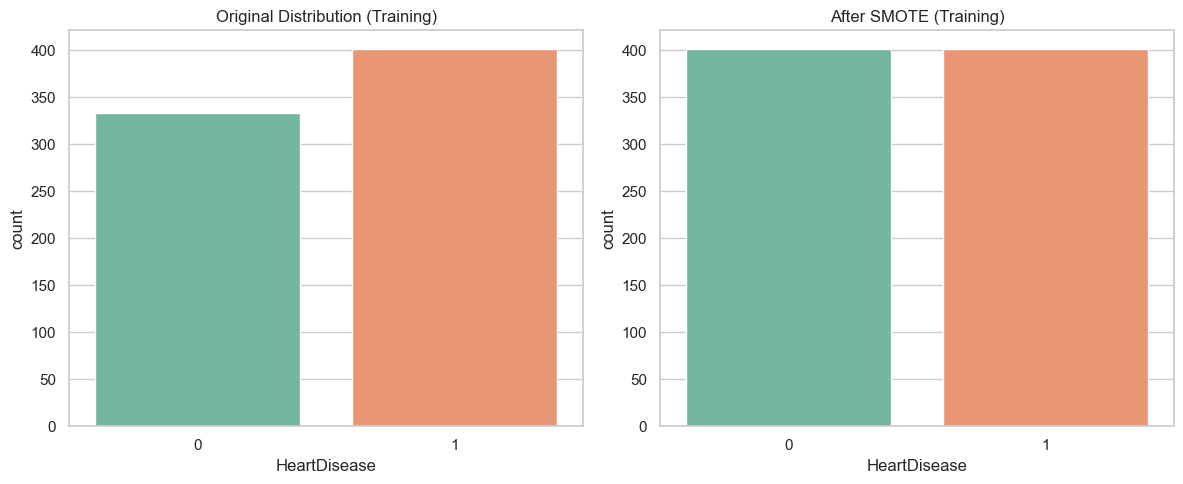

In [3]:
# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- VISUALIZATION 1: SMOTE DIFFERENCE ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=ax[0], palette='Set2')
ax[0].set_title('Original Distribution (Training)')

sns.countplot(x=y_train_smote, ax=ax[1], palette='Set2')
ax[1].set_title('After SMOTE (Training)')

plt.tight_layout()
plt.show()

### 3. Train Model

In [4]:
# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Train the model on the balanced data
gnb.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = gnb.predict(X_test)

### 4. Evaluate: Confusion Matrix & Learning Curve

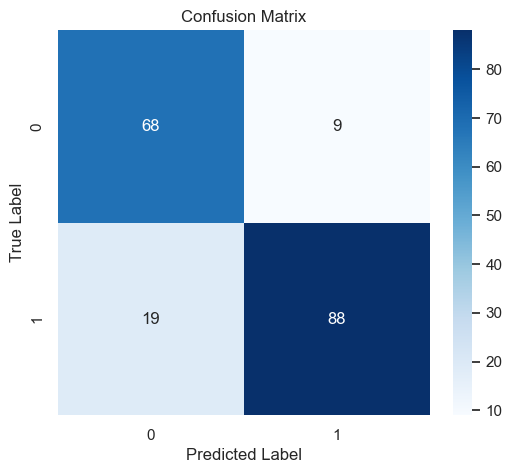

In [5]:
# --- VISUALIZATION 2: CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

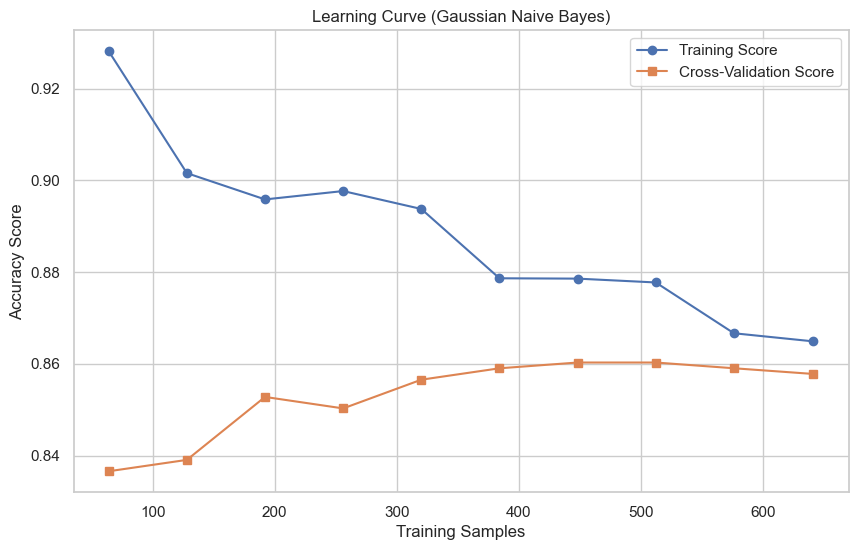

Model Accuracy: 0.8478

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [6]:
# --- VISUALIZATION 3: LEARNING CURVE ---
train_sizes, train_scores, test_scores = learning_curve(
    GaussianNB(), X_train_smote, y_train_smote, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', marker='s')
plt.title('Learning Curve (Gaussian Naive Bayes)')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Final Metrics
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))